# Introduction

### Importing important libraries

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load the dataset

In [18]:
dataset = pd.read_csv('../data/train.csv')

In [19]:
dataset.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


### Shape of dataset

In [36]:
print('The dataset has', dataset.shape[0], 'rows and', dataset.shape[1], 'columns')

The dataset has 159571 rows and 8 columns


In [21]:
print('Columns present in dataset', dataset.columns)

Columns present in dataset Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='str')


In [38]:
dataset.select_dtypes(include=['int64', 'float64']).columns

Index(['toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate'],
      dtype='str')

In [39]:
dataset.select_dtypes('object').columns

/var/folders/9k/4s141cxx4tl42lnhf8qx7wjr0000gn/T/ipykernel_11602/1833878408.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dataset.select_dtypes('object').columns


Index(['id', 'comment_text'], dtype='str')

Numeric columns correspond to the toxicity labels (0/1), while comment_text is the main textual feature.

# Basis Analysis

In [25]:
dataset.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [26]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 9.7 MB


The dataset contains 159,571 comments with no missing text entries. So there is no need to handle missing values. Lets check for duplicate values

### Check duplicate values

In [ ]:
dataset.duplicated().sum()

np.int64(0)

Check if there duplicate comments with different labels

In [46]:
dataset[dataset.duplicated(subset='comment_text', keep=False)]

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,clean



### Check missing values

In [ ]:
dataset.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
clean            0
dtype: int64

In [ ]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
dataset['clean'] = (dataset[labels].sum(axis=1)==0).astype(int)

In [ ]:
(dataset[labels].sum(axis=1) > 1).sum()

np.int64(9865)

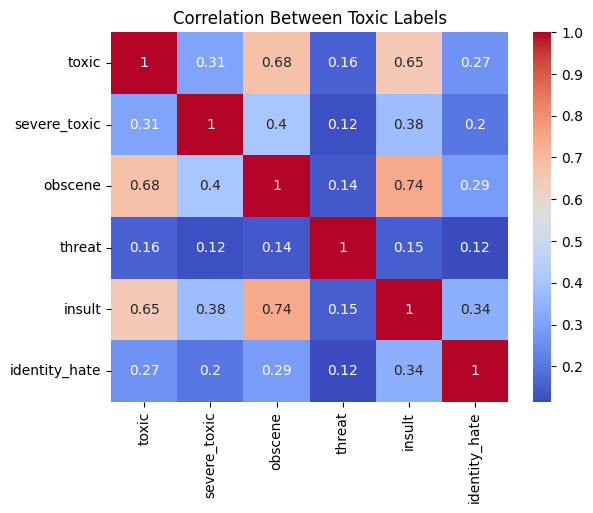

In [ ]:
sns.heatmap(dataset[labels].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Toxic Labels")
plt.show()

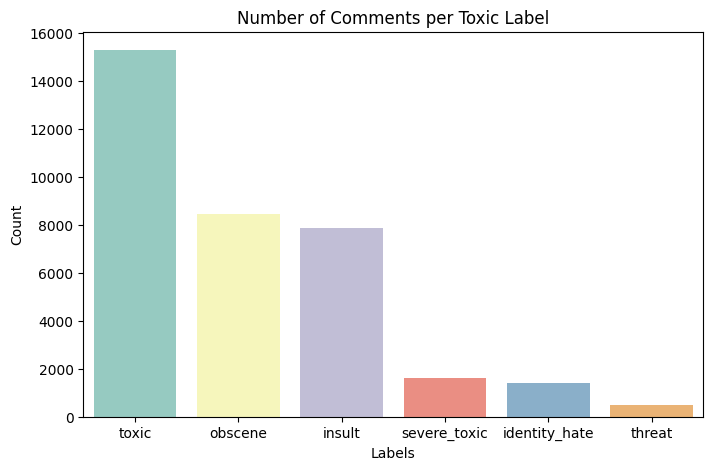

In [ ]:
# Count of each label
labels_count = dataset[labels].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(
    x=labels_count.index,
    y=labels_count.values,
    hue=labels_count.index,
    palette="Set3",
    dodge=False,  # overlap avoid
    legend=False
)
plt.title("Number of Comments per Toxic Label")
plt.ylabel("Count")
plt.xlabel("Labels")
plt.show()

### Summary of Dataset Introduction

This dataset comes from the **Kaggle Toxic Comment Classification Challenge**.  
It contains Wikipedia talk page comments labeled across six categories of toxicity:  *toxic, severe toxic, obscene, threat, insult, identity hate*.  

The dataset is **highly imbalanced**: most comments are non-toxic, and within toxic categories, *toxic*, *obscene*, and *insult* are more frequent, while *threat* and *identity_hate* are extremely rare.  